In [16]:
import pandas as pd
import numpy as np

In [17]:
data = pd.read_csv("C:\\Users\\Tharun\\Downloads\\archive (4)\\Titanic-Dataset.csv")
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# REMOVING ALL DUPLICATE AND NULL VALUES

In [21]:
data.drop('Cabin',axis = 1,inplace = True)

In [26]:
data["Age"]=data["Age"].fillna(data["Age"].mean())

In [30]:
data=data[~data["Embarked"].isnull()]

In [31]:
data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,C


In [32]:
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# FEATURE SCALING

In [50]:
df = data.select_dtypes(include = np.number)
df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.000000,1,0,7.2500
1,2,1,1,38.000000,1,0,71.2833
2,3,1,3,26.000000,0,0,7.9250
3,4,1,1,35.000000,1,0,53.1000
4,5,0,3,35.000000,0,0,8.0500
...,...,...,...,...,...,...,...
886,887,0,2,27.000000,0,0,13.0000
887,888,1,1,19.000000,0,0,30.0000
888,889,0,3,29.699118,1,2,23.4500
889,890,1,1,26.000000,0,0,30.0000


In [36]:
from sklearn.preprocessing import StandardScaler

In [63]:
df=StandardScaler().fit_transform(df)
df

array([[-1.73250451, -0.78696114,  0.82520863, ...,  0.43135024,
        -0.47432585, -0.50023975],
       [-1.72861124,  1.27071078, -1.57221121, ...,  0.43135024,
        -0.47432585,  0.78894661],
       [-1.72471797,  1.27071078,  0.82520863, ..., -0.47519908,
        -0.47432585, -0.48664993],
       ...,
       [ 1.72471797, -0.78696114,  0.82520863, ...,  0.43135024,
         2.00611934, -0.17408416],
       [ 1.72861124,  1.27071078, -1.57221121, ..., -0.47519908,
        -0.47432585, -0.0422126 ],
       [ 1.73250451, -0.78696114,  0.82520863, ..., -0.47519908,
        -0.47432585, -0.49017322]], shape=(889, 7))

In [64]:
b=pd.DataFrame(df,columns=["PassengerId","Survived","Pclass","Age","SibSp","Parch","Fare"])
b

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,-1.732505,-0.786961,0.825209,-0.590495,0.431350,-0.474326,-0.500240
1,-1.728611,1.270711,-1.572211,0.643971,0.431350,-0.474326,0.788947
2,-1.724718,1.270711,0.825209,-0.281878,-0.475199,-0.474326,-0.486650
3,-1.720825,1.270711,-1.572211,0.412509,0.431350,-0.474326,0.422861
4,-1.716931,-0.786961,0.825209,0.412509,-0.475199,-0.474326,-0.484133
...,...,...,...,...,...,...,...
884,1.716931,-0.786961,-0.373501,-0.204724,-0.475199,-0.474326,-0.384475
885,1.720825,1.270711,-1.572211,-0.821957,-0.475199,-0.474326,-0.042213
886,1.724718,-0.786961,0.825209,0.003524,0.431350,2.006119,-0.174084
887,1.728611,1.270711,-1.572211,-0.281878,-0.475199,-0.474326,-0.042213


# ENCODING

In [65]:
a=data.select_dtypes(include=['string'])

In [66]:
from sklearn.preprocessing import LabelEncoder

In [67]:
for i in a:
    a[i]=LabelEncoder().fit_transform(a[i])

In [68]:
a.head()

,Name,Sex,Ticket,Embarked
0,108,1,522,2
1,190,0,595,0
2,353,0,668,2
3,272,0,48,2
4,15,1,471,2


# COMBINING THE NUMERICAL & CATEGORICAL COLUMNS

In [90]:
df1=pd.concat([b,a],axis=1)

In [91]:
df1=df1.dropna()

# DEFINING THE TARGET AND FEATURE

In [140]:
y=df1["Survived"]
x=df1.drop(["Name","Ticket","PassengerId","Survived"],axis=1)
y = data.loc[df1.index, "Survived"]
x = df1.drop(["Name", "Ticket", "PassengerId", "Survived"], axis=1)

In [141]:
x

,Pclass,Age,SibSp,Parch,Fare,Sex,Embarked
0,0.825209,-0.590495,0.431350,-0.474326,-0.500240,1.0,2.0
1,-1.572211,0.643971,0.431350,-0.474326,0.788947,0.0,0.0
2,0.825209,-0.281878,-0.475199,-0.474326,-0.486650,0.0,2.0
3,-1.572211,0.412509,0.431350,-0.474326,0.422861,0.0,2.0
4,0.825209,0.412509,-0.475199,-0.474326,-0.484133,1.0,2.0
...,...,...,...,...,...,...,...
884,-0.373501,-0.204724,-0.475199,-0.474326,-0.384475,1.0,2.0
885,-1.572211,-0.821957,-0.475199,-0.474326,-0.042213,0.0,1.0
886,0.825209,0.003524,0.431350,2.006119,-0.174084,1.0,2.0
887,-1.572211,-0.281878,-0.475199,-0.474326,-0.042213,0.0,2.0


# TRAIN TEST SPLIT

In [142]:
from sklearn.model_selection import train_test_split

In [143]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

# MODEL DEPLOYMENT

In [144]:
from sklearn.linear_model import LogisticRegression

In [145]:
import warnings
warnings.filterwarnings("ignore")
model=LogisticRegression()
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# PREDICTED VALUES

In [146]:
y_predict=model.predict(x_test)

# METRICES

In [147]:
from sklearn.metrics import accuracy_score,classification_report

In [148]:
accuracy_score(y_test,y_predict)

0.7584269662921348

In [149]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.77      0.85      0.81       108
           1       0.73      0.61      0.67        70

    accuracy                           0.76       178
   macro avg       0.75      0.73      0.74       178
weighted avg       0.76      0.76      0.75       178



# FINAL INSIGHT

In [150]:
model.coef_[0]

array([-0.01391681, -0.00319926, -0.16465369,  0.17006038, -0.03433914,
       -2.51855115, -0.35176379])

<BarContainer object of 7 artists>

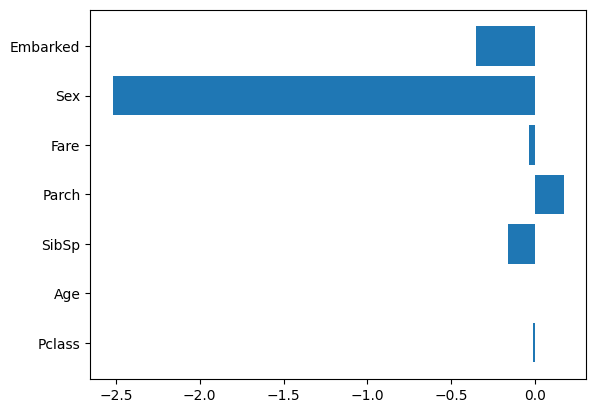

In [151]:
import matplotlib.pyplot as plt
plt.barh(x.columns,model.coef_[0])

# The visualization confirms this historical "women and children first" reality, showing that being male had a massive negative impact on survival chances